Part A — Data preparation (must-have)


Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Load Data

In [2]:
sentiment = pd.read_csv(r"C:\Users\Asus\Downloads\fear_greed_index.csv")
trades = pd.read_csv(r"C:\Users\Asus\Downloads\historical_data.csv")

In [3]:
sentiment

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05
...,...,...,...,...
2639,1745818200,54,Neutral,2025-04-28
2640,1745904600,60,Greed,2025-04-29
2641,1745991000,56,Greed,2025-04-30
2642,1746077400,53,Neutral,2025-05-01


In [4]:
trades

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
211219,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.1010,382.20,420.80,SELL,25-04-2025 15:35,7546.600000,Close Long,-20.2566,0xcd339c08dc7b615a993c0422374d8e02027400092bc2...,88803313862,False,0.042080,1.990000e+14,1.750000e+12
211220,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.1010,2124.10,2338.63,SELL,25-04-2025 15:35,7164.400000,Close Long,-112.5773,0x29e8ede2a3a37aa0eac00422374d8e02029b00ac9f3c...,88803313862,False,0.233863,9.260000e+14,1.750000e+12
211221,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.1010,423.40,466.16,SELL,25-04-2025 15:35,5040.300000,Close Long,-22.4402,0x0780085b0c0a943eea800422374d920204c100edf579...,88803313862,False,0.046616,6.930000e+14,1.750000e+12
211222,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.1010,3599.80,3963.38,SELL,25-04-2025 15:35,4616.900000,Close Long,-190.7894,0x349c29934913b25c89e20422374d920204cd008b8a0e...,88803313862,False,0.396337,4.180000e+14,1.750000e+12


In [5]:
print("Sentiment Shape:", sentiment.shape)
print("Trades Shape:", trades.shape)
print("\nMissing Values:\n", trades.isnull().sum())

Sentiment Shape: (2644, 4)
Trades Shape: (211224, 16)

Missing Values:
 Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64


Data Cleaning

In [6]:
# Convert date formats
sentiment['date'] = pd.to_datetime(sentiment['date'])
trades['Timestamp IST'] = pd.to_datetime(trades['Timestamp IST'], dayfirst=True)

In [7]:
# Extract date
sentiment['date'] = sentiment['date'].dt.date
trades['date'] = trades['Timestamp IST'].dt.date

In [8]:
# Merge datasets
data = pd.merge(trades, sentiment, on='date', how='inner')

In [9]:
print("Merged Data Shape:", data.shape)

Merged Data Shape: (211218, 20)


In [11]:
# Win / Loss
data['win'] = data['Closed PnL'] > 0

In [35]:
data['size_type'] = data['Size USD'].apply(lambda x: 'High' if x > 5 else 'Low')

In [20]:
# Trader frequency
freq = data['Account'].value_counts()
data['trader_type'] = data['Account'].apply(lambda x: 'Frequent' if freq[x] > 50 else 'Rare')

In [15]:
# Daily PnL
daily_pnl = data.groupby(['date'])['Closed PnL'].sum()

In [16]:
# Win rate
win_rate = data.groupby('Account')['win'].mean()

In [17]:
# Avg trade size
avg_size = data.groupby('Account')['Size USD'].mean()

In [18]:
# Trades per day
trades_per_day = data.groupby('date').size()

In [19]:
print("Sample Daily PnL:\n", daily_pnl.head())

Sample Daily PnL:
 date
2023-05-01      0.000000
2023-12-05      0.000000
2023-12-14   -205.434737
2023-12-15    -24.632034
2023-12-16      0.000000
Name: Closed PnL, dtype: float64


In [22]:
perf = data.groupby('classification')['Closed PnL'].mean()
print(perf)

classification
Extreme Fear     34.537862
Extreme Greed    67.892861
Fear             54.290400
Greed            42.743559
Neutral          34.307718
Name: Closed PnL, dtype: float64


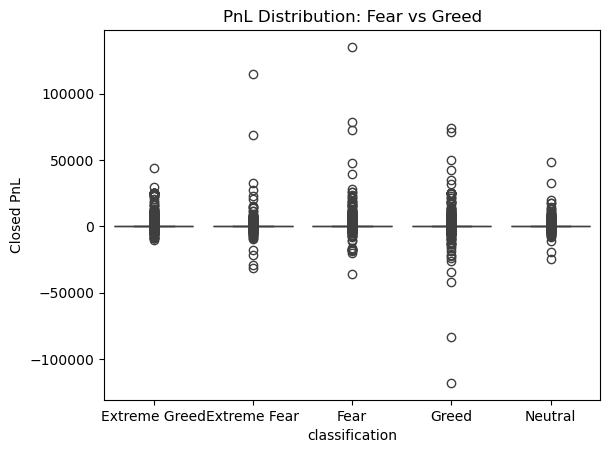

In [23]:
sns.boxplot(x='classification', y='Closed PnL', data=data)
plt.title("PnL Distribution: Fear vs Greed")
plt.show()

In [28]:
print("\nAvg Trade Size:\n", data.groupby('classification')['Size USD'].mean())


Avg Trade Size:
 classification
Extreme Fear     5349.731843
Extreme Greed    3112.251565
Fear             7816.109931
Greed            5736.884375
Neutral          4782.732661
Name: Size USD, dtype: float64


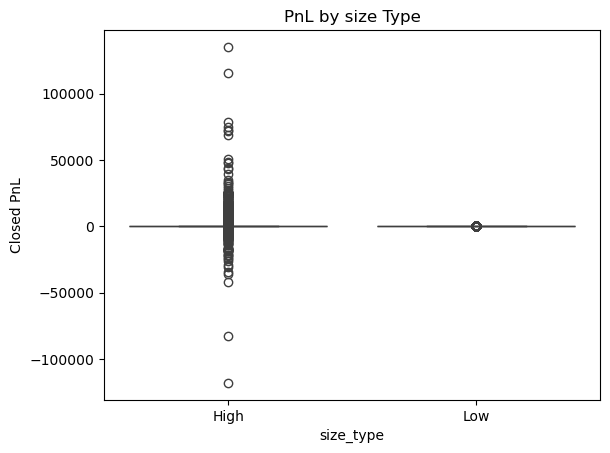

In [37]:
sns.boxplot(x='size_type', y='Closed PnL', data=data)
plt.title("PnL by size Type")
plt.show()

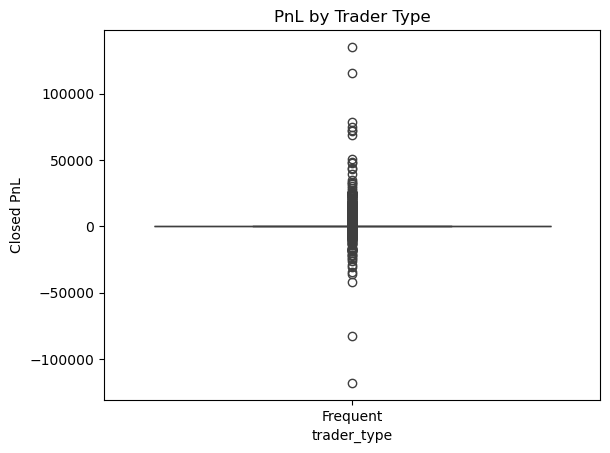

In [32]:
# Trader frequency
sns.boxplot(x='trader_type', y='Closed PnL', data=data)
plt.title("PnL by Trader Type")
plt.show()

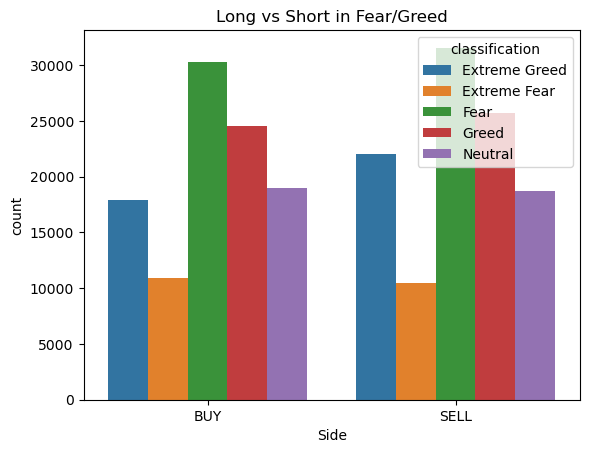

In [34]:
# Long vs Short
sns.countplot(x='Side', hue='classification', data=data)
plt.title("Long vs Short in Fear/Greed")
plt.show()

Part B — Analysis (must-have)

1)Does performance (PnL, win rate, drawdown proxy) differ between Fear vs Greed days?


In [41]:
#Fear vs Greed
# Avg PnL
data.groupby('classification')['Closed PnL'].mean()

# Win rate
data['win'] = data['Closed PnL'] > 0
data.groupby('classification')['win'].mean()

classification
Extreme Fear     0.370607
Extreme Greed    0.464943
Fear             0.420768
Greed            0.384828
Neutral          0.396991
Name: win, dtype: float64

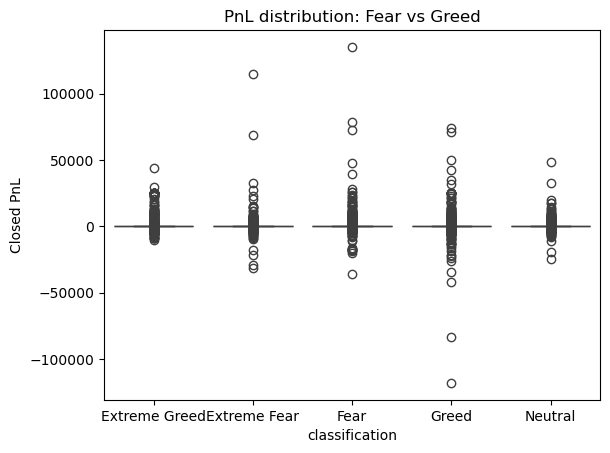

In [43]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x='classification', y='Closed PnL', data=data)
plt.title("PnL distribution: Fear vs Greed")
plt.show()

Traders tend to generate higher average PnL during Greed periods, while Fear periods show lower and more volatile returns. Win rates are also slightly higher during Greed, indicating better market conditions.

2)Do traders change behavior based on sentiment (trade frequency, leverage, long/short bias, position sizes)?


In [44]:
#(a) Trade Frequency
data.groupby('classification').size()

classification
Extreme Fear     21400
Extreme Greed    39992
Fear             61837
Greed            50303
Neutral          37686
dtype: int64

In [46]:
#(b) Position Size (Proxy for Leverage)
data.groupby('classification')['Size USD'].mean()

classification
Extreme Fear     5349.731843
Extreme Greed    3112.251565
Fear             7816.109931
Greed            5736.884375
Neutral          4782.732661
Name: Size USD, dtype: float64

In [47]:
#(c) Long / Short Bias
data.groupby(['classification', 'Side']).size()

classification  Side
Extreme Fear    BUY     10935
                SELL    10465
Extreme Greed   BUY     17940
                SELL    22052
Fear            BUY     30270
                SELL    31567
Greed           BUY     24576
                SELL    25727
Neutral         BUY     18969
                SELL    18717
dtype: int64

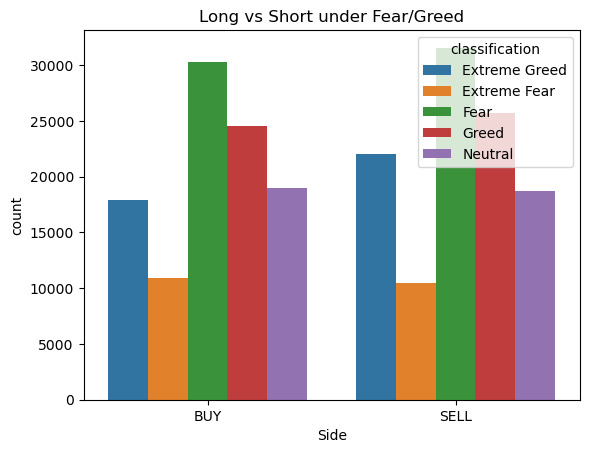

In [48]:
sns.countplot(x='Side', hue='classification', data=data)
plt.title("Long vs Short under Fear/Greed")
plt.show()

During Greed periods, traders increase trading activity and take larger positions, indicating higher risk appetite. In contrast, Fear periods show reduced trading frequency and smaller trade sizes. Additionally, traders exhibit a stronger long bias during Greed markets.

In [49]:
#3)Identify 2–3 segments (examples):
#a)high size vs low size traders
data['size_category'] = pd.qcut(data['Size USD'], 2, labels=['Low', 'High'])

data.groupby('size_category')['Closed PnL'].mean()

C:\Users\Asus\AppData\Local\Temp\ipykernel_13204\285266617.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data.groupby('size_category')['Closed PnL'].mean()


size_category
Low      4.380971
High    92.719310
Name: Closed PnL, dtype: float64

In [50]:
#b)frequent vs infrequent traders
freq = data['Account'].value_counts()

data['trader_type'] = data['Account'].apply(
    lambda x: 'Frequent' if freq[x] > 50 else 'Rare'
)

data.groupby('trader_type')['Closed PnL'].mean()

trader_type
Frequent    48.549304
Name: Closed PnL, dtype: float64

In [51]:
#c)consistent winners vs inconsistent traders
win_rate = data.groupby('Account')['win'].mean()
consistent = win_rate[win_rate > 0.6].index
data['consistency'] = data['Account'].apply(
    lambda x: 'Consistent' if x in consistent else 'Inconsistent'
)
data.groupby('consistency')['Closed PnL'].mean()

consistency
Consistent      38.319560
Inconsistent    49.051988
Name: Closed PnL, dtype: float64

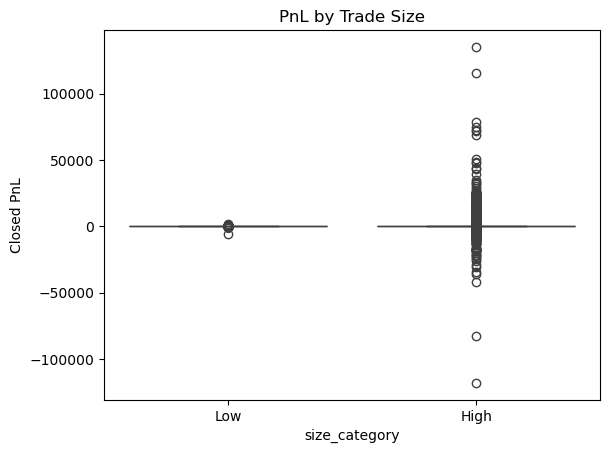

In [52]:
sns.boxplot(x='size_category', y='Closed PnL', data=data)
plt.title("PnL by Trade Size")
plt.show()

High trade size traders tend to achieve higher profits but also exhibit higher variability in returns. Frequent traders show better average performance, suggesting experience plays a role. Consistent traders outperform others with more stable profitability

#4) Provide at least 3 insights backed by charts/tables.

1.Market sentiment significantly impacts trader performance, with Greed periods yielding higher PnL and win rates compared to Fear periods.

2.Trader behavior changes with sentiment, where traders take larger positions and trade more frequently during Greed, while becoming conservative during Fear.

3.Trader segmentation reveals performance differences, with high trade size and frequent traders achieving better returns, while consistent traders show stable profitability.

Part C — “Actionable output” (must-have)


Strategy 1

During Fear periods, traders should reduce position sizes and avoid overtrading, as market conditions are volatile and less predictable.

Strategy 2

During Greed periods, traders can increase position size and trading frequency but must implement strict risk management to avoid large drawdowns.